Tune diagram with error line to draw the real Qx-Qy evolution

In [14]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import xtrack as xt
import xobjects as xo
import xpart as xp
import xcoll as xc
import json

In [15]:
def remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2):
    "Remove apertures of off-momentum BPMs which give flanges as bottlenecks"
    tt = line.get_table()
    tw = line.twiss()
    mask_disp = 5*np.sqrt(tw.betx*exn*pmass/nrj)+n_buckets*bucket_height*tw.dx > 0.025
    mask_bpm = ['bp' in name for name in tt.name]
    mask_aper = np.array(['aper' in name for name in tt.name])
    offmom_bpms = tt.name[mask_disp & mask_bpm & ~mask_aper]
    aper_to_remove = [f'{name}{suffix}' for name in offmom_bpms for suffix in ('.a_aper', '.b_aper')]
    line.remove(aper_to_remove)

In [16]:
def generate_delta_sampling(delta_min, delta_max, step=None, num_points=None):
    if step is None and num_points is None:
        raise ValueError("Either 'step' or 'num_points' must be provided.")
    if step is None:
        step = (delta_max - delta_min) / num_points

    i_min = int(np.ceil(delta_min / step))
    i_max = int(np.floor(delta_max / step))

    arr = step * np.arange(i_min, i_max + 1)
    return arr

In [17]:
def twiss_scan(line, delta_min, delta_max, step=None, num_points=None):
    delta_values = generate_delta_sampling(delta_min, delta_max, step, num_points)
    
    idx_zero = np.where(delta_values == 0)[0][0]
    tw0 = line.twiss4d(delta0=0.0)
    twisses = []
    # twiss_pos.append(tw0)
    # twiss_neg.append(tw0)

    for delta in delta_values[:idx_zero][::-1]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co) if len(twisses)>0 else tw0)
    twisses = twisses[::-1]
    twisses.append(tw0)
    for delta in delta_values[idx_zero + 1:]:
        twisses.append(line.twiss4d(delta0=delta, co_guess=twisses[-1].particle_on_co))
    
    return delta_values, twisses

In [18]:
error_variants = {
    'dipole_b3' : [0, 0, 1, 0, 0, 0],
    'dipole_b5' : [0, 0, 0, 0, 1, 0],
    'dipole_b3b5': [0, 0, 1, 0, 1, 0],
    'quadrupole_b4': [0, 0, 0, 1, 0, 0],
    'quadrupole_b6': [0, 0, 0, 0, 0, 1],
    'quadrupole_b4b6': [0, 0, 0, 1, 0, 1],
    'dipole_b3_quadrupole_b4': [0, 0, 1, 1, 0, 0],
    'all': [0, 0, 1, 1, 1, 1]
}
error_variant_name = 'all'
qx = 20.13
qy = 20.18
xi_x = 0.5
xi_y = 0.5

In [20]:
# line = xt.Line.from_json('../injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
line = xt.Line.from_json('../../injection_lines/sps_q20_inj.json')
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
# line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6

tw = line.twiss()
# remove_offmom_bpms_apers(line, exn=3.5e-6, nrj=21, pmass=0.938, bucket_height=3e-3, n_buckets=2)

# Installing errors
b1, b2, b3, b4, b5, b6 = error_variants[error_variant_name]
tte = env.elements.get_table()
mask_rbends = tte.element_type == 'RBend'
mask_quads = tte.element_type == 'Quadrupole'
mask_sextupoles = tte.element_type == 'Sextupole'

mba = tte.rows[mask_rbends].rows['mba.*'].name
mbb = tte.rows[mask_rbends].rows['mbb.*'].name
qf = tte.rows[mask_quads].rows['qf.*'].name
qd = tte.rows[mask_quads].rows['qd.*'].name
lsf = tte.rows[mask_sextupoles].rows['lsf.*'].name
lsd = tte.rows[mask_sextupoles].rows['lsd.*'].name

env.vars['qph_setvalue'] = 0.0
env.vars['qpv_setvalue'] = 0.0

# Set the strengths according to Hannes' measurements
for nn in mba:
    env[nn].knl = np.array([b1*0., b2*0., b3*2.12e-3, b4*0., b5*-5.74, b6*0.])

for nn in mbb:
    env[nn].knl = np.array([b1*0., b2*0., b3*-3.19e-3, b4*0., b5*-5.10, b6*0.])

for nn in qf:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*0.75e-1, b5*0., b6*-0.87e3])

for nn in qd:
    env[nn].knl = np.array([b1*0., b2*0., b3*0., b4*-2.03e-1, b5*0., b6*2.04e3])

env.vars['qph_setvalue'] = xi_x
env.vars['qpv_setvalue'] = xi_y
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])

Loading line from dict:   0%|          | 0/4037 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 13.73                             
Matching: model call n. 7 penalty = 2.6216e-03              
Optimize - end penalty:  0.00262155                            


# Tune analysis

In [21]:
delta_values, twisses = twiss_scan(line, -7e-3, 7e-3, step = 1e-4)

Text(0, 0.5, 'Q')

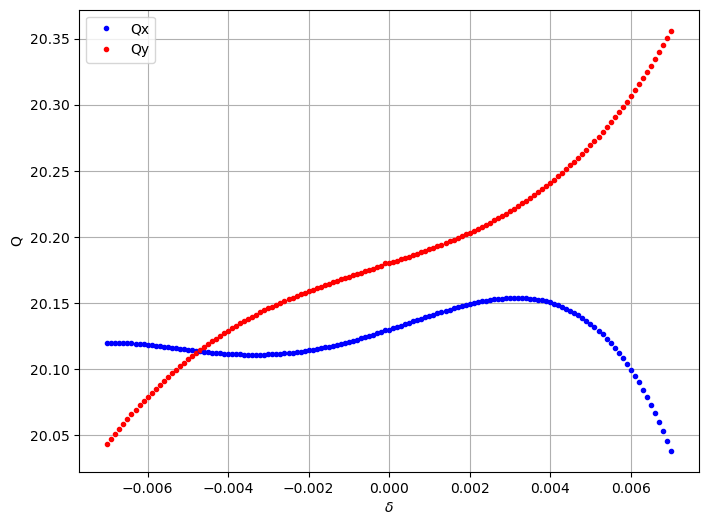

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

for delta, tw in zip(delta_values, twisses):
    ax.plot(delta, tw.qx, '.', color='blue')
    ax.plot(delta, tw.qy, '.', color='red')

handles = [
    Line2D([], [], color='blue', marker='.', linestyle='None', label='Qx'),
    Line2D([], [], color='red',  marker='.', linestyle='None', label='Qy'),
]

ax.legend(handles=handles)
ax.grid()
ax.set_xlabel(r'$\delta$')
ax.set_ylabel('Q')

When you get out of the range that was probed by the fit, you are very sensitive to higher orders (because they are already there to fit the extrema), but so they are very unstable, unreliable (Hannes). So I should restrict myself to deltas in that range...

In [23]:
tw.qx, tw.qx%20

(np.float64(20.038421323903815), np.float64(0.03842132390381536))

# Tune diagram

In [24]:
def make_line(Qx_range, Qy_range, p, q, r, ax, ls='--', color='yellowgreen'):
    if p==0:
        Qy = r/q
        ax.hlines(Qy, Qx_range[0], Qx_range[1], color=color, ls=ls)
    elif q == 0:
        Qx = r/p
        ax.vlines(Qx, Qy_range[0], Qy_range[1], color=color, ls=ls)
    
    else:
        Qx = np.linspace(Qx_range[0], Qx_range[1])
        Qy = (r-p*Qx)/q
        ax.plot(Qx, Qy, color=color, ls=ls)

In [25]:
mask = (delta_values > -4e-3) & (delta_values < 4e-3)
qxs = np.array([tw.qx for tw in twisses])
qys = np.array([tw.qy for tw in twisses])

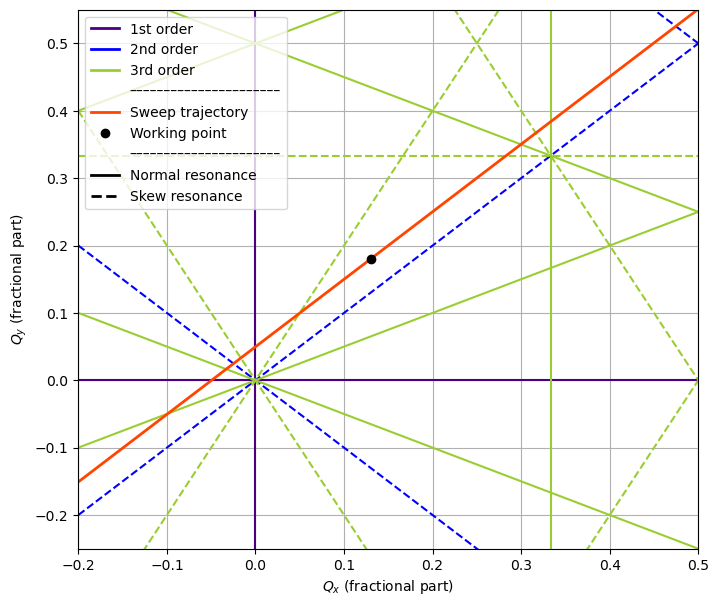

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from math import gcd, floor, ceil

# -----------------------------
# Helpers: p sampling + dedup
# -----------------------------
def legend_divider(text="-"*18):
    # Invisible handle + visible label = looks like a dashed separator row
    return mlines.Line2D([], [], linestyle="none", marker=None, color="none", label=text)

def _gcd3(a, b, c):
    return gcd(gcd(abs(a), abs(b)), abs(c))

def line_key(m, n, p):
    """
    Canonical key for the line m*Qx + n*Qy = p, modulo integer scaling.
    Prevents duplicates like (2,0,0) vs (1,0,0).
    """
    g = _gcd3(m, n, p)
    m1, n1, p1 = m // g, n // g, p // g

    # canonical sign (unique up to global -1)
    if (m1 < 0) or (m1 == 0 and n1 < 0) or (m1 == 0 and n1 == 0 and p1 < 0):
        m1, n1, p1 = -m1, -n1, -p1
    return (m1, n1, p1)

def p_values_in_box(xlim, ylim, m, n):
    """All integer p for which m*x + n*y = p intersects the rectangle."""
    xs = [xlim[0], xlim[1]]
    ys = [ylim[0], ylim[1]]
    vals = [m*x + n*y for x in xs for y in ys]
    pmin = floor(min(vals))
    pmax = ceil(max(vals))
    return range(pmin, pmax + 1)

def primitive_mn(m, n):
    """Reduce (m,n) to primitive gcd(|m|,|n|)=1 with a fixed sign convention."""
    g = gcd(abs(m), abs(n))
    m0, n0 = m // g, n // g
    if (m0 < 0) or (m0 == 0 and n0 < 0):
        m0, n0 = -m0, -n0
    return m0, n0

def mn_possibilities_of_order(order):
    """
    Generate unique primitive (m,n) with |m|+|n| == order.
    This ensures e.g. 2Qx=p is not duplicated with Qx=p.
    """
    out = set()
    for m in range(-order, order + 1):
        for n in range(-order, order + 1):
            if m == 0 and n == 0:
                continue
            m0, n0 = primitive_mn(m, n)
            if abs(m0) + abs(n0) == order:
                out.add((m0, n0))
    return sorted(out)

def plot_mn_family(ax, xlim, ylim, mn_list, color, linestyle, plotted, make_line):
    """For each (m,n), sample p and plot if not already plotted."""
    for (m, n) in mn_list:
        for p in p_values_in_box(xlim, ylim, m, n):
            k = line_key(m, n, p)
            if k in plotted:
                continue
            plotted.add(k)
            make_line(xlim, ylim, m, n, p, ax, color=color, ls=linestyle)

# -----------------------------
# Your inputs / styling
# -----------------------------
colours = {1: 'indigo', 2: 'blue', 3: 'yellowgreen'}
ls      = {'normal' : '-', 'skew' : '--'}

xlim = (-0.2, 0.5)
ylim = (-0.25, 0.55)

# Use EXACTLY the possibilities you provided:
third_order_normal = [(3, 0), (-1, 0), (1, 2), (-1, 2), (-1, 0)]
third_order_skew   = [(0, 3), (0, -1), (2, 1), (-2, 1), (0, 1)]

# Dedup any repeated (m,n) in the lists (e.g. (-1,0) appears twice)
third_order_normal = list(dict.fromkeys(third_order_normal))
third_order_skew   = list(dict.fromkeys(third_order_skew))

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(8, 7))
plotted = set()

# 1st + 2nd order: generate (m,n), sample p, dedup plotted lines
for order, type_res in zip((1, 2), ('normal', 'skew')):
    mn_list = mn_possibilities_of_order(order)
    plot_mn_family(ax, xlim, ylim, mn_list, colours[order], ls[type_res], plotted, make_line)

# 3rd order normal + skew: your fixed families, sample p, dedup
plot_mn_family(ax, xlim, ylim, third_order_normal, colours[3], ls['normal'], plotted, make_line)
plot_mn_family(ax, xlim, ylim, third_order_skew,   colours[3], ls['skew'], plotted, make_line)

# Sweep trajectory + working point
# qx_gen = np.linspace(xlim[0], xlim[1], 1000)
# ax.plot(qx_gen, 20.18/20.13 * (qx_gen - 0.13) + 0.18, color='orangered', lw=2)
ax.plot(qxs[mask]-20, qys[mask]-20, color='orangered', lw=2)
# ax.plot(qxs-20, qys-20, color='orangered', lw=2)
ax.scatter(0.13, 0.18, color='k', zorder=5)



# Axes
ax.grid(True)
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Legend (upper left)
handles = [
    mlines.Line2D([], [], color=colours[1], ls=ls['normal'], lw=2, label="1st order"),
    mlines.Line2D([], [], color=colours[2], ls=ls['normal'], lw=2, label="2nd order"),
    mlines.Line2D([], [], color=colours[3], ls=ls['normal'], lw=2, label="3rd order"),

    legend_divider("–"*22),

    mlines.Line2D([], [], color="orangered", lw=2, label="Sweep trajectory"),
    mlines.Line2D([], [], color="k", marker="o", ls="None", markersize=6, label="Working point"),
    
    legend_divider("–"*22),
    
    mlines.Line2D([], [], color="k", ls="-", lw=2, label="Normal resonance"),
    mlines.Line2D([], [], color="k", ls="--", lw=2, label="Skew resonance"),
]
ax.legend(handles=handles, loc="upper left", frameon=True)
ax.set_xlabel(r"$Q_x$ (fractional part)")
ax.set_ylabel(r"$Q_y$ (fractional part)")
plt.show()
